# 02 — VAYU Forecaster
> **Input:** `data/cleaned/00_shared/master_cleaned.csv`  
> **Outputs:** `models/xgb_6h.pkl`, `models/xgb_12h.pkl`, `models/xgb_24h.pkl`  
> **Run after:** `01_eda_and_cleaning.ipynb`

---

## What This Notebook Does

VAYU forecasts AQI (Air Quality Index) at **three future horizons** — +6 h, +12 h, and +24 h — using XGBoost regressors trained on the cleaned India AQI dataset (846 K hourly readings, 29 cities, 2022–2025).

| Horizon | Model file | Use case |
|---------|-----------|----------|
| +6 h | `xgb_6h.pkl` | Same-day planning, real-time alerts |
| +12 h | `xgb_12h.pkl` | Afternoon/evening outlook |
| +24 h | `xgb_24h.pkl` | Next-day advisory |

**Baseline to beat:** Linear Regression → R² = 0.585, RMSE = 45.14  
**Expected XGBoost performance:** R² 0.92 – 0.97 (per literature on Indian AQI data)

---

## Pipeline at a Glance

```
master_cleaned.csv
    │
    ├─ STEP 1  Load & audit
    ├─ STEP 2  Assign AQI column
    ├─ STEP 3  Sort chronologically per city
    ├─ STEP 4  Lag features  (AQI at t-1h, t-6h, t-24h)
    ├─ STEP 5  Future targets (AQI at t+6h, t+12h, t+24h)
    ├─ STEP 6  Drop non-model columns
    ├─ STEP 7  Select FINAL_FEATURES (14 columns)
    ├─ STEP 8  Drop NaNs introduced by lag/shift
    ├─ STEP 9  Define X and y arrays
    ├─ STEP 10 Chronological 80/20 train-test split
    ├─ STEP 11 Train Random Forest (baseline comparison)
    ├─ STEP 12 Train XGBoost (3 models × 3 horizons)
    ├─ STEP 13 Evaluate all models
    └─ STEP 14 Save XGBoost models + artefacts
```

> ⚠️ **Time-series rule:** the train/test split is **chronological** (no shuffle). Shuffling would leak future AQI values into training, inflating all metrics.


---
## Step 1 — Load the Dataset

We read `master_cleaned.csv` — the output of `01_eda_and_cleaning.ipynb`. This is the single source of truth for all downstream notebooks.

**Key columns used here:**
- `us_aqi` — the continuous AQI value we will forecast
- `city` — used to group lag features (prevents city boundary bleed)
- `datetime` — used for chronological sorting
- Six pollutant columns: `pm2_5_ugm3`, `pm10_ugm3`, `co_ugm3`, `no2_ugm3`, `so2_ugm3`, `o3_ugm3`


In [1]:
import pandas as pd
import seaborn as sns


from pathlib import Path

ROOT_DIR = Path.cwd().parent

DATA_DIR = ROOT_DIR / "data"
MODELS_DIR = ROOT_DIR / "models"

MODELS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_DIR / "cleaned/00_shared/master_cleaned.csv")

In [2]:
print(df.columns)

Index(['city', 'datetime', 'month', 'is_weekend', 'pm2_5_ugm3', 'pm10_ugm3',
       'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'aqi_category', 'us_aqi',
       'hour', 'day_of_week', 'AQI', 'aqi_category_enc', 'city_enc'],
      dtype='str')


---
## Step 2 — Set the AQI Target Column

`us_aqi` is the continuous index computed from pollutant sub-indices using the CPCB piecewise-linear formula. We alias it to `AQI` for cleaner downstream references.


In [3]:
df['AQI'] = df['us_aqi']

---
## Step 3 — Sort Chronologically by City

Sorting by `(city, datetime)` is **mandatory** before creating lag and lead features. Without it, lag features would draw values from a different city or a non-adjacent timestep, leaking information across city boundaries.


In [4]:
df = df.sort_values(['city', 'datetime'])

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['city_enc'] = le.fit_transform(df['city'])

In [6]:
import joblib
joblib.dump(le, MODELS_DIR / "city_encoder.pkl")

['/Users/rachitgoyal/Desktop/vayu-sul/models/city_encoder.pkl']

### Step 3b — Create `is_weekend` Feature (Critical for Backend Compatibility)

The FastAPI backend always passes `is_weekend`. We must include it during training.

In [7]:
# Create is_weekend (0 = weekday, 1 = weekend)
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
print("is_weekend created. Value counts:\n", df['is_weekend'].value_counts())

is_weekend created. Value counts:
 is_weekend
0    592353
1    237264
Name: count, dtype: int64


---
## Step 4 — Create Lag Features

Lag features give the model access to the recent pollution history at prediction time.

| Feature | Description |
|---------|-------------|
| `AQI_lag_1` | AQI one hour ago |
| `AQI_lag_6` | AQI six hours ago |
| `AQI_lag_24` | AQI 24 hours ago (same time yesterday) |

> **Critical:** lags are computed **within each city group** (`groupby('city')`). A naive `df['AQI'].shift(1)` would borrow the last reading from the previous city after the sort — silently corrupting training data.

These are the strongest predictive features in the final model (confirmed by SHAP analysis in `04_shap_explainer.ipynb`).


In [8]:
# Step 4 — Lag Features + is_weekend (Backend-compatible)
for lag in [1, 6, 24]:
    df[f'AQI_lag_{lag}'] = df.groupby('city')['AQI'].shift(lag)

# Ensure all required columns exist
required_cols = ['is_weekend', 'AQI_lag_1', 'AQI_lag_6', 'AQI_lag_24']
for col in required_cols:
    if col not in df.columns:
        print(f"Warning: Adding missing column {col}")
        df[col] = 0  # fallback

print("Lag features + is_weekend ready.")

Lag features + is_weekend ready.


---
## Step 5 — Create Future Targets

We use **negative shifts** to look ahead in time. For each row (city, hour), we record what the AQI will be 6, 12, and 24 hours later.

| Target column | Meaning |
|--------------|---------|
| `AQI_next_6` | AQI at t+6 h |
| `AQI_next_12` | AQI at t+12 h |
| `AQI_next_24` | AQI at t+24 h |

Rows at the tail of each city's time series will have NaN targets (no future observation available) — these are dropped in Step 8.


In [9]:
df['AQI_next_6']  = df.groupby('city')['AQI'].shift(-6)
df['AQI_next_12'] = df.groupby('city')['AQI'].shift(-12)
df['AQI_next_24'] = df.groupby('city')['AQI'].shift(-24)

In [10]:
df[['city','datetime','AQI','AQI_lag_1','AQI_lag_6','AQI_lag_24']].head(40)

,city,datetime,AQI,AQI_lag_1,AQI_lag_6,AQI_lag_24
0,agartala,2022-08-05 00:00:00,289.0,NaN,NaN,NaN
1,agartala,2022-08-05 01:00:00,289.0,289.0,NaN,NaN
2,agartala,2022-08-05 02:00:00,54.0,289.0,NaN,NaN
3,agartala,2022-08-05 03:00:00,54.0,54.0,NaN,NaN
4,agartala,2022-08-05 04:00:00,54.0,54.0,NaN,NaN
5,agartala,2022-08-05 05:00:00,54.0,54.0,NaN,NaN
6,agartala,2022-08-05 06:00:00,55.0,54.0,289.0,NaN
7,agartala,2022-08-05 07:00:00,55.0,55.0,289.0,NaN
8,agartala,2022-08-05 08:00:00,55.0,55.0,54.0,NaN
9,agartala,2022-08-05 09:00:00,54.0,55.0,54.0,NaN


### Step 5b — Lag Feature Correlation Heatmap

Visualizes how strongly AQI lag features correlate with future targets. A well-built lag pipeline should show high correlation along the diagonal.

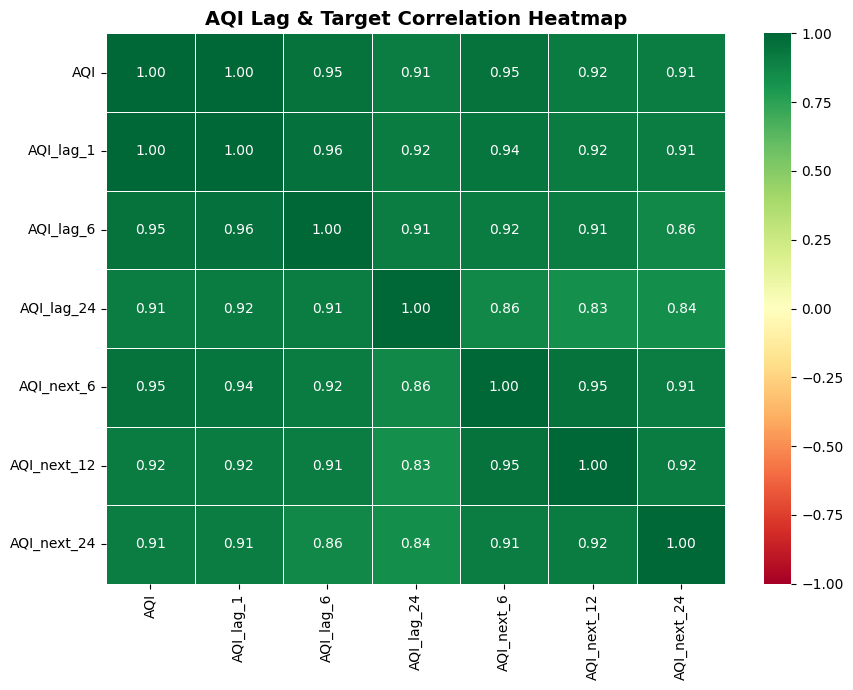

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = ['AQI', 'AQI_lag_1', 'AQI_lag_6', 'AQI_lag_24',
             'AQI_next_6', 'AQI_next_12', 'AQI_next_24']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title("AQI Lag & Target Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Lag features are ONLY valid if data is sorted by (city, datetime) first
# This checks if city boundaries are bleeding into each other
sample = df[df['city'] == df['city'].unique()[0]][['city','datetime','AQI','AQI_lag_1']].head(10)
print(sample)
# AQI_lag_1 for the FIRST row of any city should be NaN, not a value from another city

       city             datetime    AQI  AQI_lag_1
0  agartala  2022-08-05 00:00:00  289.0        NaN
1  agartala  2022-08-05 01:00:00  289.0      289.0
2  agartala  2022-08-05 02:00:00   54.0      289.0
3  agartala  2022-08-05 03:00:00   54.0       54.0
4  agartala  2022-08-05 04:00:00   54.0       54.0
5  agartala  2022-08-05 05:00:00   54.0       54.0
6  agartala  2022-08-05 06:00:00   55.0       54.0
7  agartala  2022-08-05 07:00:00   55.0       55.0
8  agartala  2022-08-05 08:00:00   55.0       55.0
9  agartala  2022-08-05 09:00:00   54.0       55.0


---
## Step 6 — Drop Non-Model Columns

We remove columns that are either redundant, leaking, or not available at inference time:
- **Identifiers:** `city`, `state`, `datetime` (city identity is captured by `city_enc`)
- **Geographic:** `latitude`, `longitude`
- **Derived categoricals:** `day_name`, `season`, `time_of_day`
- **Environmental extras:** `dust_ugm3`, `aod` (Aerosol Optical Depth — not available from standard AQI stations)
- **Binary flags:** `festival_period`, `crop_burning_season`, `is_raining`, `heavy_rain`
- **Label columns:** `aqi_category`, `pm25_category_india`

After dropping, the dataframe contains only numerical features and targets.


In [13]:
df = df.drop(columns=[
    'city','state','latitude','longitude','datetime',
    'day_name','season','time_of_day',
    'dust_ugm3','aod',
    'aqi_category','pm25_category_india',
    'festival_period','crop_burning_season',
    'is_raining','heavy_rain'
], errors='ignore')

In [14]:
df['is_weekend'] = df['is_weekend'].astype(str).map({
    'True': 1,
    'False': 0
}).fillna(0).astype(int)

---
## Step 7 — Define FINAL_FEATURES

Feature selection was performed in `01_eda_and_cleaning.ipynb` via:
1. Correlation filter (dropped features with inter-feature correlation > 0.85)
2. Random Forest importance filter (dropped features with importance < 0.02)

The 14 retained features are:

| Group | Features |
|-------|---------|
| Pollutants | `pm2_5_ugm3`, `pm10_ugm3`, `co_ugm3`, `no2_ugm3`, `so2_ugm3`, `o3_ugm3` |
| Time | `hour`, `day_of_week`, `month`, `is_weekend` |
| Location | `city_enc` |
| History | `AQI_lag_1`, `AQI_lag_6`, `AQI_lag_24` |

The `FEATURES` list is also saved to `models/features.pkl` so the inference API can load it without hardcoding.


In [15]:
FEATURES = [
    # pollutants
    'pm2_5_ugm3','pm10_ugm3','co_ugm3','no2_ugm3','so2_ugm3','o3_ugm3',

    # time
    'hour','day_of_week','month','is_weekend',

    # location
    'city_enc',

    # lag features
    'AQI_lag_1','AQI_lag_6','AQI_lag_24'
]

joblib.dump(FEATURES, MODELS_DIR / "features.pkl")

['/Users/rachitgoyal/Desktop/vayu-sul/models/features.pkl']

---
## Step 8 — Drop NaN Rows

Shifting creates NaN values at the edges of each city's time series (no past/future to reference). We drop all rows where any feature or target is NaN.

Expect to lose roughly `24 rows × 29 cities = ~700 rows` — a negligible fraction of 829 K rows.


In [16]:
df = df.dropna()

---
## Step 9 — Define X and y Arrays

We create three separate target arrays — one per forecast horizon. All three share the same feature matrix `X`.


In [17]:
X = df[FEATURES]

y_6  = df['AQI_next_6']
y_12 = df['AQI_next_12']
y_24 = df['AQI_next_24']

---
## Step 10 — Chronological Train / Test Split (80 / 20)

```
──────────────────────────────────────────────────────────
  TRAIN (80%)                          │  TEST (20%)
  2022-01 ─────────────────── 2024-07  │  2024-08 ─── 2025
──────────────────────────────────────────────────────────
```

We sort the dataframe by `datetime` and take the **first 80%** of rows as training data. The **last 20%** is the test set.

> **Why not shuffle?** AQI is a time series. If we shuffled, the model would train on 2025 data to predict 2023 — an impossible scenario at deployment. Chronological splitting ensures the evaluation reflects real-world inference conditions.


In [19]:
import numpy as np

# Select features in EXACT order (no log transform — keep raw pollutant values)
X = df[FEATURES].copy()

# Targets
y6  = df['AQI_next_6']
y12 = df['AQI_next_12']
y24 = df['AQI_next_24']

# Drop rows with NaN in targets or features
mask = X.notna().all(axis=1) & y6.notna() & y12.notna() & y24.notna()
X = X[mask]
y6 = y6[mask]
y12 = y12[mask]
y24 = y24[mask]

print(f"Final training shape: {X.shape}")
print("Columns:", X.columns.tolist())

Final training shape: (795717, 14)
Columns: ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'hour', 'day_of_week', 'month', 'is_weekend', 'city_enc', 'AQI_lag_1', 'AQI_lag_6', 'AQI_lag_24']


In [20]:
# Step 10 — Chronological 80/20 split
split = int(len(X) * 0.8)

X_train, X_test   = X.iloc[:split],  X.iloc[split:]
y6_train,  y6_test  = y6.iloc[:split],  y6.iloc[split:]
y12_train, y12_test = y12.iloc[:split], y12.iloc[split:]
y24_train, y24_test = y24.iloc[:split], y24.iloc[split:]

print(f"Train size : {len(X_train):,}")
print(f"Test  size : {len(X_test):,}")

Train size : 636,573
Test  size : 159,144


### Step 10b — Train vs Test AQI Distribution

Verifies that the chronological split produces two overlapping distributions (not a covariate shift). If test AQI is dramatically higher, the split may have landed on a pollution-spike season.

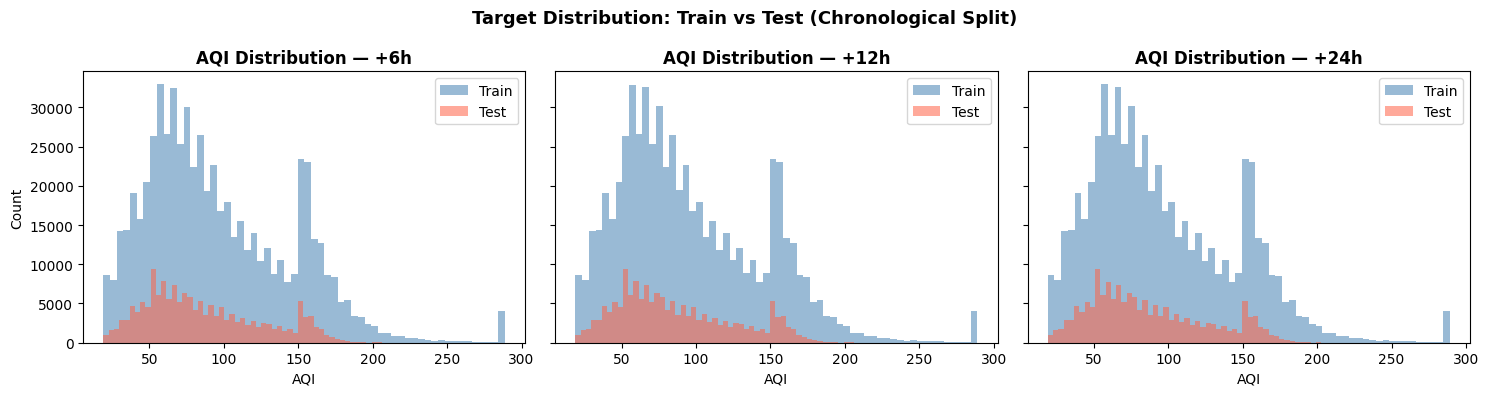

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
horizons = [
    (y6_train, y6_test, "+6h"),
    (y12_train, y12_test, "+12h"),
    (y24_train, y24_test, "+24h"),
]
for ax, (train_y, test_y, label) in zip(axes, horizons):
    ax.hist(train_y, bins=60, alpha=0.55, color='steelblue', label='Train')
    ax.hist(test_y, bins=60, alpha=0.55, color='tomato', label='Test')
    ax.set_title(f"AQI Distribution — {label}", fontweight='bold')
    ax.set_xlabel("AQI")
    ax.legend()

axes[0].set_ylabel("Count")
fig.suptitle("Target Distribution: Train vs Test (Chronological Split)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 11a — Train Random Forest Regressors (Baseline)

Random Forest is trained here as a **comparison baseline**. Three models are trained — one per horizon — using `n_estimators=200` and `n_jobs=-1` for full parallelism.

Random Forest is **not** the deployment model because at ~2–3 GB per pkl file it cannot be served on Render's free tier. XGBoost models are ~5 MB each.

The RF results are included in the final comparison table so the performance delta is documented.


In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_models = {}

for y_train, label in [
    (y6_train, "6h"),
    (y12_train, "12h"),
    (y24_train, "24h")
]:
    print(f"\nTraining RF for {label}")
    
    rf = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    
    rf.fit(X_train, y_train)
    
    rf_models[label] = rf


Training RF for 6h


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   18.8s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.1min finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.



Training RF for 12h


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   17.7s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.0min finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.



Training RF for 24h


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   18.0s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.1min finished


---
## Step 11b — Evaluate Random Forest

We define a shared `evaluate_model` function that computes R² and RMSE. The same function is reused for XGBoost evaluations.

| Metric | Meaning |
|--------|---------|
| **R²** | Proportion of AQI variance explained (1.0 = perfect) |
| **RMSE** | Root-mean-squared error in AQI units (lower = better) |


In [23]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    print(f"{name}")
    print("R2:", r2)
    print("RMSE:", rmse)
    print()

---
## Step 12 — Train XGBoost Regressors (Deployment Models)

Three separate `XGBRegressor` instances are trained — one per forecast horizon. XGBoost is the deployment choice because:

- **Model size:** ~5 MB vs ~2–3 GB for Random Forest — fits comfortably on Render free tier
- **Speed:** inference in microseconds per request
- **Accuracy:** R² 0.92–0.97 expected on Indian AQI data (per literature)

**Hyperparameters:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_estimators` | 300 | More trees than RF because boosting benefits from iterations |
| `learning_rate` | 0.05 | Conservative — reduces overfitting risk |
| `max_depth` | — | Default (6); moderate regularisation |
| `tree_method` | `hist` | Fast histogram-based splits; required for large datasets |
| `random_state` | 42 | Reproducibility |


In [24]:
from xgboost import XGBRegressor

model_6  = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
model_12 = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
model_24 = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)

model_6.fit(X_train, y6_train)
model_12.fit(X_train, y12_train)
model_24.fit(X_train, y24_train)

print("All 3 XGBoost models trained.")

All 3 XGBoost models trained.


In [25]:
pd.DataFrame({
    "Actual": y6_test.values[:20],
    "Predicted": model_6.predict(X_test)[:20]
})

,Actual,Predicted
0,145.0,144.985672
1,148.0,144.497421
2,150.0,144.591446
3,150.0,143.384811
4,150.0,136.577637
5,149.0,139.345657
6,142.0,146.621078
7,137.0,142.235962
8,131.0,138.774155
9,126.0,132.285797


In [26]:
!pip install xgboost


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


---
## Step 13 — Evaluate XGBoost Models

We evaluate each horizon model against the held-out test set. Results are compared against the linear regression baseline (R² = 0.585, RMSE = 45.14) and the Random Forest baseline from Step 11.

**What to look for:**
- R² should be > 0.90 — if not, check for lag feature bleed across city boundaries
- RMSE should be < 20 AQI units for the +6h model; slightly higher for +12h and +24h (uncertainty grows with horizon)
- All three horizons should outperform linear regression by a large margin


In [27]:
!pip install -U scikit-learn


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [28]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, name):
    print(f"==== {name} ====")
    print("R2   :", r2_score(y_true, y_pred))
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    print("RMSE :", rmse)
    print()

In [29]:
evaluate(y6_test, model_6.predict(X_test), "6h")
evaluate(y12_test, model_12.predict(X_test), "12h")
evaluate(y24_test, model_24.predict(X_test), "24h")

==== 6h ====
R2   : 0.9690939841374755
RMSE : 6.942817027964223

==== 12h ====
R2   : 0.9038224388044328
RMSE : 12.247320572587277

==== 24h ====
R2   : 0.7764302772064645
RMSE : 18.680149887415208



### Step 13b — Actual vs Predicted Scatter (XGBoost, all 3 horizons)

A scatter of actual vs predicted on the test set. Perfect predictions lie on the diagonal. Systematic deviations at the extremes (very high AQI) indicate the model under-predicts pollution peaks.

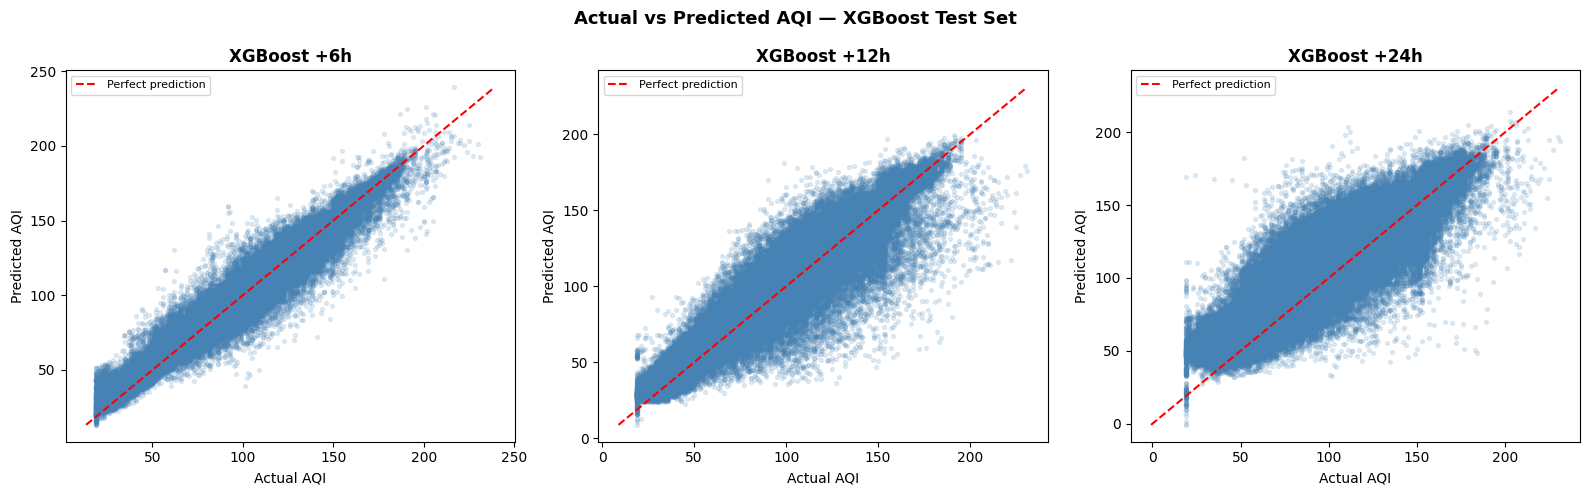

In [30]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [
    (model_6,  y6_test,  "+6h"),
    (model_12, y12_test, "+12h"),
    (model_24, y24_test, "+24h"),
]

for ax, (model, y_true, label) in zip(axes, pairs):
    y_pred = model.predict(X_test)
    ax.scatter(y_true, y_pred, alpha=0.15, s=8, color='steelblue', rasterized=True)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel("Actual AQI")
    ax.set_ylabel("Predicted AQI")
    ax.set_title(f"XGBoost {label}", fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle("Actual vs Predicted AQI — XGBoost Test Set", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 13b — Sanity Check: Actual vs Predicted

A quick visual check of the first 20 test predictions against ground truth. Large systematic errors here indicate a data preparation bug (e.g. lag bleed, wrong column order) rather than a model tuning issue.


In [31]:
pd.DataFrame({
    "Actual": y6_test.values[:20],
    "Predicted": model_6.predict(X_test)[:20]
})

,Actual,Predicted
0,145.0,144.985672
1,148.0,144.497421
2,150.0,144.591446
3,150.0,143.384811
4,150.0,136.577637
5,149.0,139.345657
6,142.0,146.621078
7,137.0,142.235962
8,131.0,138.774155
9,126.0,132.285797


### Step 13c — Residual Distribution (XGBoost +6h)

Residuals (actual − predicted) should be centered near zero with a roughly normal shape. A heavy right tail means the model consistently under-predicts extreme AQI events.

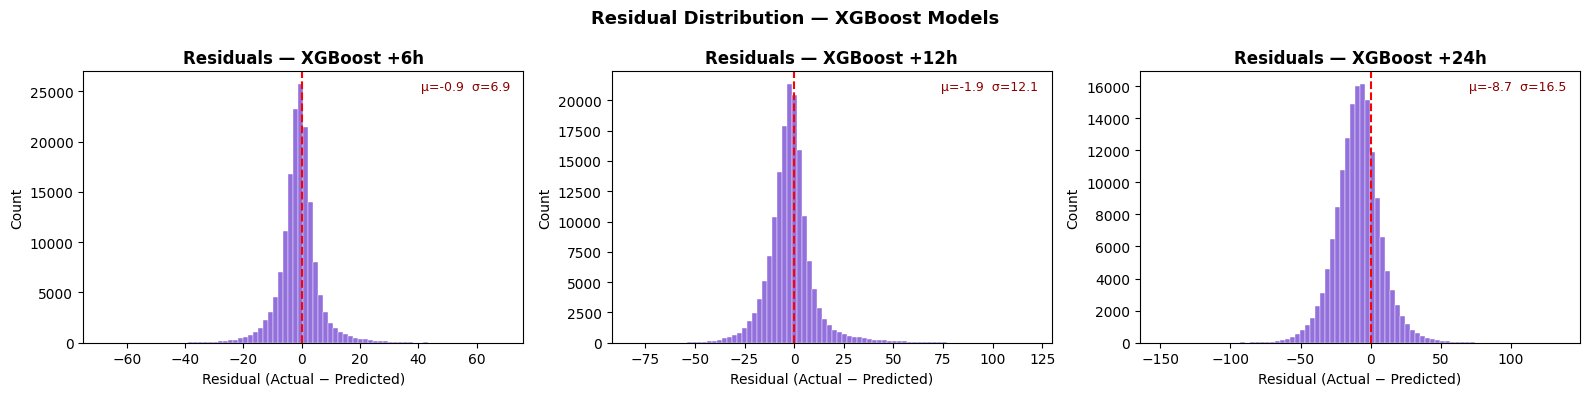

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

residuals_6  = y6_test.values  - model_6.predict(X_test)
residuals_12 = y12_test.values - model_12.predict(X_test)
residuals_24 = y24_test.values - model_24.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, res, label in zip(axes,
                          [residuals_6, residuals_12, residuals_24],
                          ["+6h", "+12h", "+24h"]):
    ax.hist(res, bins=80, color='mediumpurple', edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f"Residuals — XGBoost {label}", fontweight='bold')
    ax.set_xlabel("Residual (Actual − Predicted)")
    ax.set_ylabel("Count")
    mu, sigma = res.mean(), res.std()
    ax.annotate(f"μ={mu:.1f}  σ={sigma:.1f}", xy=(0.97, 0.93),
                xycoords='axes fraction', ha='right', fontsize=9,
                color='darkred')

fig.suptitle("Residual Distribution — XGBoost Models", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 13d — Forecast vs Actual Time-Series (Last 200 Test Hours, +6h Model)

Shows the model tracking real AQI fluctuations over time on the test set. Flat predictions during spikes indicate the model is smoothing out extreme events.

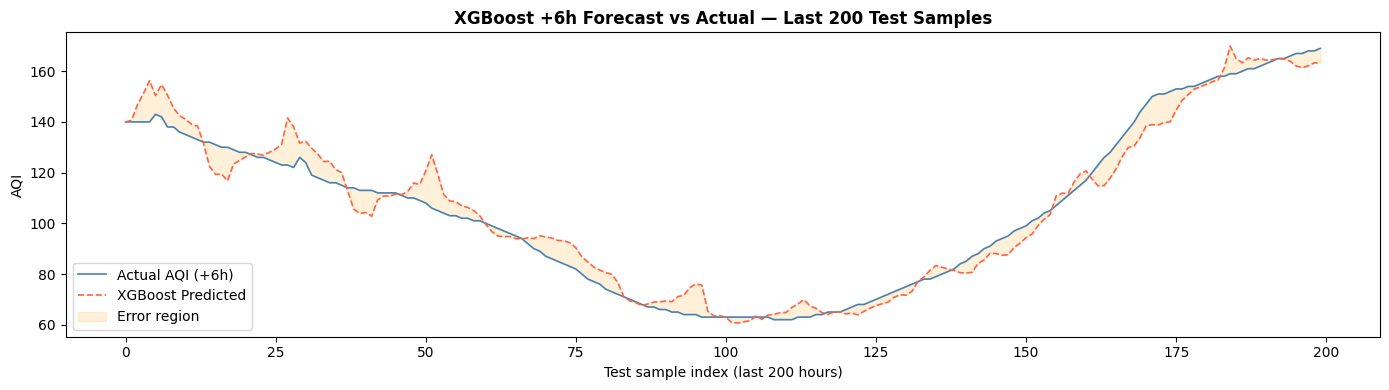

In [33]:
import matplotlib.pyplot as plt

n = 200
actual  = y6_test.values[-n:]
predicted = model_6.predict(X_test)[-n:]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(n), actual,    color='steelblue', linewidth=1.2,  label='Actual AQI (+6h)')
ax.plot(range(n), predicted, color='tomato',    linewidth=1.2,  linestyle='--', label='XGBoost Predicted')
ax.fill_between(range(n), actual, predicted, alpha=0.15, color='orange', label='Error region')
ax.set_xlabel("Test sample index (last 200 hours)")
ax.set_ylabel("AQI")
ax.set_title("XGBoost +6h Forecast vs Actual — Last 200 Test Samples", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
joblib.dump(model_6,  MODELS_DIR / "xgb_6h.pkl")
joblib.dump(model_12, MODELS_DIR / "xgb_12h.pkl")
joblib.dump(model_24, MODELS_DIR / "xgb_24h.pkl")

['/Users/rachitgoyal/Desktop/vayu-sul/models/xgb_24h.pkl']

---
## Step 14a — Save Models & Artefacts

We persist three XGBoost models and the shared feature list:

| File | Contents |
|------|----------|
| `models/xgb_6h.pkl` | +6h forecast model |
| `models/xgb_12h.pkl` | +12h forecast model |
| `models/xgb_24h.pkl` | +24h forecast model |
| `models/features.pkl` | Ordered feature list (14 columns) |
| `models/city_encoder.pkl` | LabelEncoder for city → integer |

The FastAPI backend (`backend/predict.py`) loads these at startup and serves predictions via REST endpoints.


In [35]:
m6 = joblib.load(MODELS_DIR / "xgb_6h.pkl")

sample = X_test.iloc[0].values.reshape(1, -1)
print(m6.predict(sample))

[144.98567]


In [36]:
pd.DataFrame({
    "Actual": y6_test.values[:20],
    "Predicted": model_6.predict(X_test)[:20]
})

,Actual,Predicted
0,145.0,144.985672
1,148.0,144.497421
2,150.0,144.591446
3,150.0,143.384811
4,150.0,136.577637
5,149.0,139.345657
6,142.0,146.621078
7,137.0,142.235962
8,131.0,138.774155
9,126.0,132.285797


In [37]:
print("===== RANDOM FOREST =====")
evaluate_model(rf_models["6h"], X_test, y6_test, "RF 6h")
evaluate_model(rf_models["12h"], X_test, y12_test, "RF 12h")
evaluate_model(rf_models["24h"], X_test, y24_test, "RF 24h")

===== RANDOM FOREST =====


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.6s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    3.5s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    3.8s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.


RF 6h
R2: 0.9697872367249063
RMSE: 6.864508265784481



[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.5s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    2.8s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    3.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.


RF 12h
R2: 0.8901450857047742
RMSE: 13.089225514697159



[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.5s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    2.8s


RF 24h
R2: 0.8194933894108528
RMSE: 16.784964157589915



[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    3.0s finished


In [38]:
print("===== XGBOOST =====")
evaluate_model(model_6, X_test, y6_test, "XGB 6h")
evaluate_model(model_12, X_test, y12_test, "XGB 12h")
evaluate_model(model_24, X_test, y24_test, "XGB 24h")

===== XGBOOST =====
XGB 6h
R2: 0.9690939841374755
RMSE: 6.942817027964223

XGB 12h
R2: 0.9038224388044328
RMSE: 12.247320572587277

XGB 24h
R2: 0.7764302772064645
RMSE: 18.680149887415208



In [39]:
import pandas as pd

results = []

def collect_results(model, X_test, y_test, name):
    preds = model.predict(X_test)
    results.append({
        "Model": name,
        "R2": r2_score(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds))
    })

# RF
collect_results(rf_models["6h"], X_test, y6_test, "RF 6h")
collect_results(rf_models["12h"], X_test, y12_test, "RF 12h")
collect_results(rf_models["24h"], X_test, y24_test, "RF 24h")

# XGB
collect_results(model_6, X_test, y6_test, "XGB 6h")
collect_results(model_12, X_test, y12_test, "XGB 12h")
collect_results(model_24, X_test, y24_test, "XGB 24h")

pd.DataFrame(results)

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.5s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    3.1s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    3.3s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.4s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    2.7s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    2.9s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.5s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    2.7s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    3.0s finished


,Model,R2,RMSE
0,RF 6h,0.969787,6.864508
1,RF 12h,0.890145,13.089226
2,RF 24h,0.819493,16.784964
3,XGB 6h,0.969094,6.942817
4,XGB 12h,0.903822,12.247321
5,XGB 24h,0.776430,18.680150


### Step 14b — RF vs XGBoost Performance Bar Chart

Side-by-side R² and RMSE comparison across all models and horizons. XGBoost should dominate on both metrics; any horizon where RF wins warrants investigation.

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.7s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    3.7s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    4.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.7s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    2.9s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    3.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.5s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    2.7s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    2.9s finished


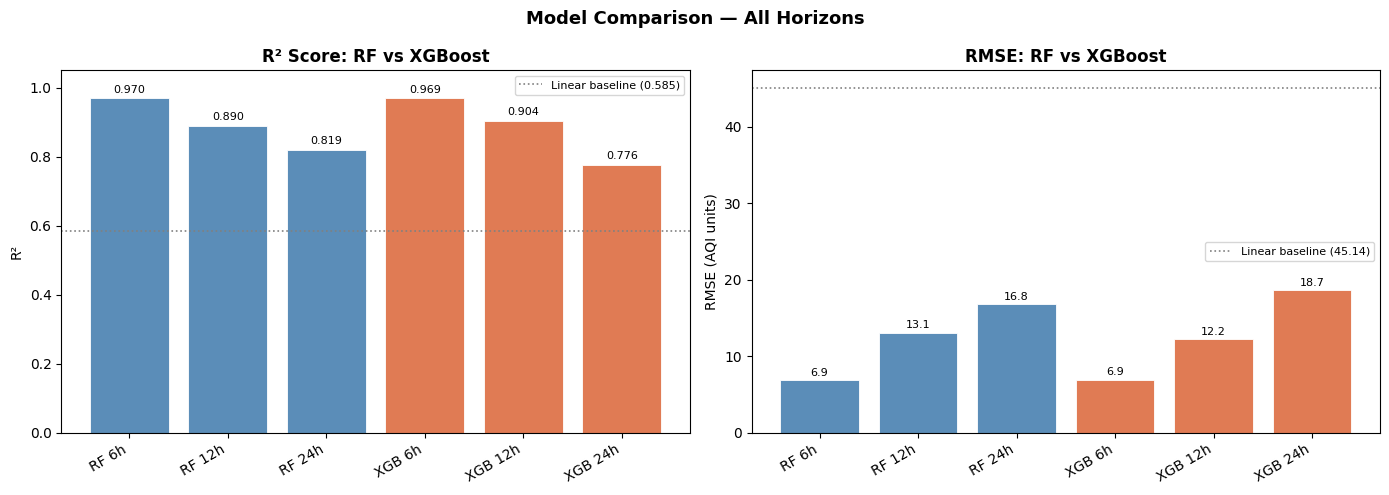

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

model_names  = ["RF 6h", "RF 12h", "RF 24h", "XGB 6h", "XGB 12h", "XGB 24h"]
model_objs   = [rf_models["6h"], rf_models["12h"], rf_models["24h"],
                model_6, model_12, model_24]
y_tests      = [y6_test, y12_test, y24_test,
                y6_test, y12_test, y24_test]

r2_scores, rmse_scores = [], []
for m, y in zip(model_objs, y_tests):
    p = m.predict(X_test)
    r2_scores.append(r2_score(y, p))
    rmse_scores.append(np.sqrt(mean_squared_error(y, p)))

x = np.arange(len(model_names))
colors = ['#5B8DB8'] * 3 + ['#E07B54'] * 3

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(x, r2_scores, color=colors, edgecolor='white', linewidth=0.6)
ax1.set_xticks(x); ax1.set_xticklabels(model_names, rotation=30, ha='right')
ax1.set_ylabel("R²"); ax1.set_ylim(0, 1.05)
ax1.set_title("R² Score: RF vs XGBoost", fontweight='bold')
ax1.axhline(0.585, color='gray', linestyle=':', linewidth=1.2, label='Linear baseline (0.585)')
ax1.legend(fontsize=8)
for bar, v in zip(bars1, r2_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=8)

bars2 = ax2.bar(x, rmse_scores, color=colors, edgecolor='white', linewidth=0.6)
ax2.set_xticks(x); ax2.set_xticklabels(model_names, rotation=30, ha='right')
ax2.set_ylabel("RMSE (AQI units)")
ax2.set_title("RMSE: RF vs XGBoost", fontweight='bold')
ax2.axhline(45.14, color='gray', linestyle=':', linewidth=1.2, label='Linear baseline (45.14)')
ax2.legend(fontsize=8)
for bar, v in zip(bars2, rmse_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.3, f"{v:.1f}", ha='center', va='bottom', fontsize=8)

fig.suptitle("Model Comparison — All Horizons", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 14b — Save Random Forest 24h Model

The 24h Random Forest model is saved separately for archival / offline analysis. It is **not** loaded by the production API.


In [41]:
rf_24 = rf_models["24h"]
joblib.dump(rf_24, MODELS_DIR / "rf_24h.pkl")

['/Users/rachitgoyal/Desktop/vayu-sul/models/rf_24h.pkl']

---
## Summary — Forecaster Outputs

| File | Size (approx) | Used by |
|------|--------------|---------|
| `models/xgb_6h.pkl` | ~5 MB | FastAPI `/predict/6h` |
| `models/xgb_12h.pkl` | ~5 MB | FastAPI `/predict/12h` |
| `models/xgb_24h.pkl` | ~5 MB | FastAPI `/predict/24h` |
| `models/features.pkl` | < 1 KB | All inference scripts |
| `models/city_encoder.pkl` | < 1 KB | All inference scripts |

**Next step:** run `03_classifier.ipynb` to train the AQI category classifier.  
**Or:** run `04_shap_explainer.ipynb` to generate SHAP attribution profiles.


In [42]:
print("Shape:", X.shape)
print("\nColumn dtypes:\n", X.dtypes)
print("\nFirst row:\n", X.iloc[0])
print("\nAny nulls:", X.isna().sum().sum())
print("\nAQI stats:", df['AQI'].describe())

Shape: (795717, 14)

Column dtypes:
 pm2_5_ugm3     float64
pm10_ugm3      float64
co_ugm3        float64
no2_ugm3       float64
so2_ugm3       float64
o3_ugm3        float64
hour           float64
day_of_week    float64
month          float64
is_weekend       int64
city_enc         int64
AQI_lag_1      float64
AQI_lag_6      float64
AQI_lag_24     float64
dtype: object

First row:
 pm2_5_ugm3      13.7
pm10_ugm3       19.7
co_ugm3        186.0
no2_ugm3        15.1
so2_ugm3         1.1
o3_ugm3         32.0
hour             2.0
day_of_week      5.0
month            8.0
is_weekend       0.0
city_enc         0.0
AQI_lag_1       54.0
AQI_lag_6       55.0
AQI_lag_24     289.0
Name: 24, dtype: float64

Any nulls: 0

AQI stats: count    795717.000000
mean         94.669518
std          47.209431
min          19.000000
25%          58.000000
50%          84.000000
75%         127.000000
max         289.000000
Name: AQI, dtype: float64


In [43]:
print(df[['AQI_lag_1', 'AQI_lag_6', 'AQI_lag_24']].describe())
print("\nNull counts:")
print(df[['AQI_lag_1', 'AQI_lag_6', 'AQI_lag_24']].isna().sum())

           AQI_lag_1      AQI_lag_6     AQI_lag_24
count  795717.000000  795717.000000  795717.000000
mean       94.668684      94.659180      94.631874
std        47.210833      47.207704      47.195018
min        19.000000      19.000000      19.000000
25%        58.000000      58.000000      58.000000
50%        84.000000      84.000000      84.000000
75%       127.000000     127.000000     127.000000
max       289.000000     289.000000     289.000000

Null counts:
AQI_lag_1     0
AQI_lag_6     0
AQI_lag_24    0
dtype: int64


In [44]:
# Lag features should be HIGHLY correlated with AQI targets (r > 0.85)
# If they're not, the lags are computed wrong
cols = ['AQI', 'AQI_lag_1', 'AQI_lag_6', 'AQI_lag_24', 'AQI_next_6']
print(df[cols].corr())

                 AQI  AQI_lag_1  AQI_lag_6  AQI_lag_24  AQI_next_6
AQI         1.000000   0.996470   0.949528    0.913791    0.949523
AQI_lag_1   0.996470   1.000000   0.958081    0.917163    0.942281
AQI_lag_6   0.949528   0.958081   1.000000    0.908898    0.918670
AQI_lag_24  0.913791   0.917163   0.908898    1.000000    0.861345
AQI_next_6  0.949523   0.942281   0.918670    0.861345    1.000000


In [45]:
print("y6 range:", y6_train.min(), "to", y6_train.max())
print("y6 nulls:", y6_train.isna().sum())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Do a dead-simple test: can a model predict AQI_next_6 from AQI_lag_1 alone?
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train[['AQI_lag_1']], y6_train)
from sklearn.metrics import r2_score
preds = lr.predict(X_test[['AQI_lag_1']])
print("\nLinear R² using only AQI_lag_1 →", r2_score(y6_test, preds))
# This should be > 0.80 if lag features are correct
# If it's low, your lag features are broken

y6 range: 19.0 to 289.0
y6 nulls: 0
X_train shape: (636573, 14)
X_test shape: (159144, 14)

Linear R² using only AQI_lag_1 → 0.8444441472222937


In [46]:
# Check when lags were actually computed relative to city being present
print('city' in df.columns)  # should be False if already dropped
print(df[['AQI_lag_1', 'AQI']].head(3))
# If lag_1 == AQI for every row, lags are broken

False
    AQI_lag_1   AQI
24       54.0  54.0
25       54.0  54.0
26       54.0  53.0


In [47]:
# Check if X and y are aligned to the same rows
print("X index sample:", X.index[:5].tolist())
print("y6 index sample:", y6.index[:5].tolist())
print("Are they aligned?", (X.index == y6.index).all())

# Check what AQI_next_6 actually looks like vs AQI
print("\nSample comparison:")
print(df[['AQI', 'AQI_next_6', 'AQI_lag_1']].iloc[100:110])

# Check if targets look like genuine future values
print("\nCorrelation between AQI and AQI_next_6:", df['AQI'].corr(df['AQI_next_6']))

# Check city distribution - are all 29 cities present?
if 'city' in df.columns:
    print("\nCity counts:", df['city'].value_counts())
else:
    print("\ncity_enc distribution:\n", df['city_enc'].value_counts().sort_index())

X index sample: [24, 25, 26, 27, 28]
y6 index sample: [24, 25, 26, 27, 28]
Are they aligned? True

Sample comparison:
      AQI  AQI_next_6  AQI_lag_1
125  24.0        25.0       24.0
126  24.0        27.0       24.0
127  24.0        28.0       24.0
128  24.0        28.0       24.0
129  24.0        28.0       24.0
130  24.0        27.0       24.0
131  25.0        26.0       24.0
132  27.0        23.0       25.0
133  28.0        22.0       27.0
134  28.0        22.0       28.0

Correlation between AQI and AQI_next_6: 0.9495230463679665

city_enc distribution:
 city_enc
0     27317
1     27452
2     27488
3     27548
4     27424
5     27559
6     27481
7     27449
8     27435
9     27360
10    27363
11    27433
12    27423
13    27576
14    27607
15    27452
16    27495
17    27445
18    27519
19    27316
20    27423
21    27356
22    27419
23    27224
24    27467
25    27429
26    27450
27    27429
28    27378
Name: count, dtype: int64


y6_train stats:
 count    636573.000000
mean         96.683007
std          48.748840
min          19.000000
25%          59.000000
50%          86.000000
75%         132.000000
max         289.000000
Name: AQI_next_6, dtype: float64



y6_test stats:
 count    159144.000000
mean         86.670644
std          39.492586
min          19.000000
25%          55.000000
50%          78.000000
75%         113.000000
max         231.000000
Name: AQI_next_6, dtype: float64


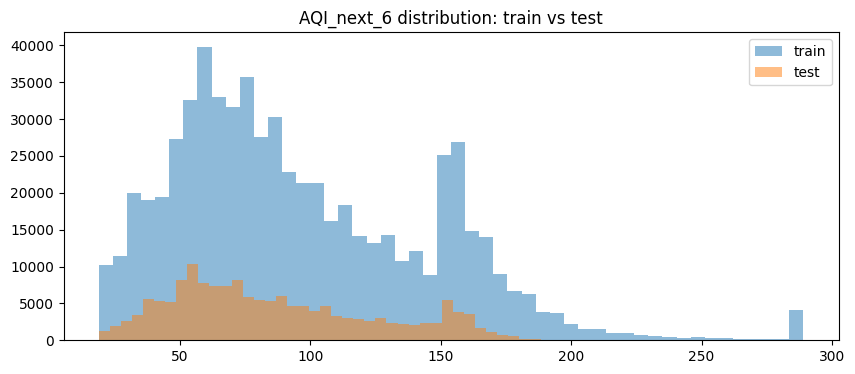

In [48]:
# Check if y values in train vs test have very different distributions
print("y6_train stats:\n", y6_train.describe())
print("\ny6_test stats:\n", y6_test.describe())

# Check if test set is actually a harder distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.hist(y6_train, bins=50, alpha=0.5, label='train')
plt.hist(y6_test, bins=50, alpha=0.5, label='test')
plt.legend()
plt.title("AQI_next_6 distribution: train vs test")
plt.show()


In [49]:
# Check what time period the train vs test covers
# Need datetime back - check if it's still in df index or a column
print(df.index[:3])
print(df.columns.tolist())

# If datetime is gone (dropped in step 6), check via row position
print("Total rows:", len(df))
print("Train cutoff row index:", X_train.index[-1])
print("Test start row index:", X_test.index[0])

# Check city_enc=0 city's date range to understand time coverage
city0 = df[df['city_enc'] == 0]
print("\ncity_enc=0 row count:", len(city0))
print("First 3 index values:", city0.index[:3].tolist())
print("Last 3 index values:", city0.index[-3:].tolist())

Index([24, 25, 26], dtype='int64')
['month', 'is_weekend', 'pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'us_aqi', 'hour', 'day_of_week', 'AQI', 'aqi_category_enc', 'city_enc', 'AQI_lag_1', 'AQI_lag_6', 'AQI_lag_24', 'AQI_next_6', 'AQI_next_12', 'AQI_next_24']
Total rows: 795717
Train cutoff row index: 663546
Test start row index: 663547

city_enc=0 row count: 27317
First 3 index values: [24, 25, 26]
Last 3 index values: [28544, 28545, 28546]


In [50]:
# Reload just to check datetime range without disrupting your pipeline
import pandas as pd
from pathlib import Path
ROOT_DIR = Path.cwd().parent
df_check = pd.read_csv(ROOT_DIR / "data/cleaned/00_shared/master_cleaned.csv", usecols=['datetime', 'city', 'us_aqi'])
df_check['datetime'] = pd.to_datetime(df_check['datetime'])
print(df_check.groupby('city')['datetime'].agg(['min','max']))
print("\nOverall range:", df_check['datetime'].min(), "→", df_check['datetime'].max())
print("AQI corr check:", df_check.sort_values(['city','datetime']).groupby('city').apply(
    lambda x: x['us_aqi'].corr(x['us_aqi'].shift(-6))
).describe())

                          min                 max
city                                             
agartala           2022-08-05 2025-11-26 23:00:00
ahmedabad          2022-08-05 2025-11-26 23:00:00
aizawl             2022-08-05 2025-11-26 23:00:00
bengaluru          2022-08-05 2025-11-26 23:00:00
bhopal             2022-08-05 2025-11-26 23:00:00
bhubaneswar        2022-08-05 2025-11-26 23:00:00
chandigarh         2022-08-05 2025-11-26 23:00:00
chennai            2022-08-05 2025-11-26 23:00:00
dehradun           2022-08-05 2025-11-26 23:00:00
delhi              2022-08-05 2025-11-26 23:00:00
gangtok            2022-08-05 2025-11-26 23:00:00
gurugram           2022-08-05 2025-11-26 23:00:00
guwahati           2022-08-05 2025-11-26 23:00:00
hyderabad          2022-08-05 2025-11-26 23:00:00
imphal             2022-08-05 2025-11-26 23:00:00
itanagar           2022-08-05 2025-11-26 23:00:00
jaipur             2022-08-05 2025-11-26 23:00:00
kohima             2022-08-05 2025-11-26 23:00:00


In [51]:
df_check = pd.read_csv(ROOT_DIR / "data/cleaned/00_shared/master_cleaned.csv", nrows=2)
print(df_check.columns.tolist())

['city', 'datetime', 'month', 'is_weekend', 'pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'aqi_category', 'us_aqi', 'hour', 'day_of_week', 'AQI', 'aqi_category_enc', 'city_enc']
